### 01 - Imports (unsloth)

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["WANDB_DISABLED"] = "true"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import warnings
warnings.filterwarnings("ignore")

# unsloth must be imported before everything else
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

import json
import gc
import torch
import pandas as pd
from PIL import Image
from transformers import TrainerCallback, EarlyStoppingCallback
from trl import SFTConfig, SFTTrainer
from qwen_vl_utils import process_vision_info

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device:  {device}")
print(f"GPU:     {torch.cuda.get_device_name(0)}")
print(f"VRAM:    {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Device:  cuda
GPU:     NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM:    6.1 GB


### 02 - Config

In [ ]:
MODEL_ID       = "Qwen/Qwen2-VL-2B-Instruct"
MODEL_NAME     = "qwen2vl_2b"
TUNING_VERSION = "A"
AI2D_DIR       = "/kaggle/working/ai2d"
DATA_DIR       = "/kaggle/working/data"
CKPT_DIR       = f"/kaggle/working/checkpoints/{MODEL_NAME}_tuning{TUNING_VERSION}"
LOG_DIR        = f"/kaggle/working/logs/{MODEL_NAME}_tuning{TUNING_VERSION}"
RESULTS_DIR    = "/kaggle/working/results"

for d in [CKPT_DIR, LOG_DIR, DATA_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"✓ {d}")

HW_CONFIG = {
    "batch_size":             2,
    "gradient_accumulation":  4,
    "lora_r":                 8,
    "lora_alpha":             16,
    "lora_dropout":           0.05,
    "learning_rate":          2e-4,
    "warmup_ratio":           0.03,
    "epochs":                 3,
    "optim":                  "adamw_8bit",
    "gradient_checkpointing": True,
    "logging_steps":          10,
    "eval_steps":             500,
    "save_steps":             500,
    "save_total_limit":       5,
    "early_stopping_patience": 3,
    "early_stopping_threshold": 0.01,
}

print("\nHyperparameters:")
for k, v in HW_CONFIG.items():
    print(f"  {k}: {v}")

#### local inference

In [1]:
AI2D_DIR   = "../ai2d"          # your local ai2d folder
DATA_DIR   = "../processed_data" # where your splits are
CKPT_DIR   = "../checkpoints/qwen2vl_2b_tuningA/final"  # extracted zip
LOG_DIR    = "../logs/qwen2vl_2b_tuningA"
RESULTS_DIR = "../results"

### 03 - Download AI2D

In [ ]:
import subprocess

print("Downloading AI2D...")
subprocess.run([
    "wget", "-q",
    "https://ai2-public-datasets.s3.amazonaws.com/diagrams/ai2d-all.zip",
    "-O", "/kaggle/working/ai2d.zip"
], check=True)

subprocess.run([
    "unzip", "-q", "/kaggle/working/ai2d.zip",
    "-d", "/kaggle/working/"
], check=True)

print("✓ Done")
!ls /kaggle/working/ai2d/

### 04 - Build Dataset Splits

In [ ]:
import random
from collections import defaultdict

random.seed(42)

with open(f"{AI2D_DIR}/categories.json") as f:
    categories = json.load(f)

all_questions = []
for fname in os.listdir(f"{AI2D_DIR}/questions"):
    if not fname.endswith(".json"):
        continue
    with open(f"{AI2D_DIR}/questions/{fname}") as f:
        q_data = json.load(f)
    image_name = q_data.get("imageName", "")
    for q_text, q in q_data.get("questions", {}).items():
        all_questions.append({
            "image_name":           image_name,
            "question_id":          q.get("questionId", ""),
            "question_text":        q_text,
            "abc_label":            q.get("abcLabel", False),
            "answer_texts":         " | ".join(q.get("answerTexts", [])),
            "correct_answer_index": q.get("correctAnswer", 0),
        })

df_q = pd.DataFrame(all_questions)
img_q_counts = df_q.groupby("image_name").size().reset_index(name="q_count")
valid_images  = img_q_counts[img_q_counts["q_count"] > 0]["image_name"].tolist()

print(f"Total questions: {len(df_q)}")
print(f"Valid images:    {len(valid_images)}")

by_category = defaultdict(list)
for img in valid_images:
    by_category[categories.get(img, "other")].append(img)

train_imgs, val_imgs, test_imgs = [], [], []
for cat, imgs in by_category.items():
    random.shuffle(imgs)
    n      = len(imgs)
    n_test = max(1, int(n * 0.15))
    n_val  = max(1, int(n * 0.15))
    test_imgs  += imgs[:n_test]
    val_imgs   += imgs[n_test:n_test + n_val]
    train_imgs += imgs[n_test + n_val:]

assert not set(train_imgs) & set(val_imgs)
assert not set(train_imgs) & set(test_imgs)
assert not set(val_imgs)   & set(test_imgs)
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)} ✓")

### 05 - Build annotation context and samples

In [ ]:
def build_annotation_context(image_name):
    ann_path = f"{AI2D_DIR}/annotations/{image_name}.json"
    if not os.path.exists(ann_path):
        return ""
    with open(ann_path) as f:
        ann = json.load(f)

    texts         = ann.get("text", {})
    relationships = ann.get("relationships", {})

    label_map   = {}
    for tid, t in texts.items():
        val  = t.get("value", "").strip()
        repl = t.get("replacementText", "").strip()
        if val:
            label_map[tid] = f"{val}({repl})" if repl else val

    connections = []
    title       = None
    for rel in relationships.values():
        cat        = rel.get("category", "")
        origin_str = label_map.get(rel.get("origin", ""))
        dest_str   = label_map.get(rel.get("destination", ""))
        if cat == "imageTitle" and origin_str:
            title = origin_str
        elif cat == "intraObjectLabel":
            if origin_str and dest_str:
                connections.append(f"{origin_str} labels {dest_str}")
            elif origin_str:
                connections.append(f"{origin_str} → visual region")
        elif cat == "intraObjectLinkage" and origin_str:
            connections.append(f"{origin_str} → visual region")

    context = ""
    if title:
        context += f"Diagram title: {title}\n"
    if label_map:
        context += f"Diagram labels: {', '.join(label_map.values())}\n"
    if connections:
        context += "Connections:\n" + "\n".join(f"  {c}" for c in connections) + "\n"
    return context


def build_samples(image_names, version="A"):
    samples = []
    options = ["A", "B", "C", "D"]
    for img_name in image_names:
        q_rows      = df_q[df_q["image_name"] == img_name]
        ann_context = build_annotation_context(img_name) if version == "B" else ""
        for _, row in q_rows.iterrows():
            answers     = row["answer_texts"].split(" | ")
            correct_idx = int(row["correct_answer_index"])
            choices_str = "  ".join(f"{options[i]}) {ans}" for i, ans in enumerate(answers))
            question_str = row["question_text"]
            if row["abc_label"]:
                question_str = "[Label Question] " + question_str
            samples.append({
                "image_name":    img_name,
                "image_path":    f"{AI2D_DIR}/images/{img_name}",
                "category":      categories.get(img_name, "other"),
                "question_id":   row["question_id"],
                "abc_label":     bool(row["abc_label"]),
                "user_text":     f"{ann_context}Question: {question_str}\n{choices_str}",
                "answer":        f"{options[correct_idx]}) {answers[correct_idx]}",
                "correct_index": correct_idx,
                "version":       version,
            })
    return samples


os.makedirs(f"{DATA_DIR}/splits", exist_ok=True)
for split_name, split_imgs in [
    ("train", train_imgs), ("val", val_imgs), ("test", test_imgs)
]:
    for ver in ["A", "B"]:
        samples  = build_samples(split_imgs, version=ver)
        out_path = f"{DATA_DIR}/splits/{split_name}_v{ver}.json"
        with open(out_path, "w") as f:
            json.dump(samples, f)
        print(f"✓ {out_path}  ({len(samples)} samples)")

### 06 - Load and format data

In [ ]:
SYSTEM_PROMPT = (
    "You are a VLM specialized in scientific diagram understanding. "
    "Answer multiple-choice questions about diagrams by selecting the correct option. "
    "Respond ONLY with the letter and answer text in this exact format: X) answer text. "
    "Example: C) stem"
)

with open(f"{DATA_DIR}/splits/train_vA.json") as f:
    train_data = json.load(f)
with open(f"{DATA_DIR}/splits/val_vA.json") as f:
    val_data = json.load(f)

print(f"Train: {len(train_data)} | Val: {len(val_data)}")

def format_sample(sample):
    return {
        "messages": [
            {"role": "system",    "content": [{"type": "text",  "text": SYSTEM_PROMPT}]},
            {"role": "user",      "content": [
                {"type": "image", "image": sample["image_path"]},
                {"type": "text",  "text": sample["user_text"]},
            ]},
            {"role": "assistant", "content": [{"type": "text",  "text": sample["answer"]}]},
        ]
    }

train_dataset = [format_sample(s) for s in train_data]
val_dataset   = [format_sample(s) for s in val_data]
print(f"✓ Formatted {len(train_dataset)} train | {len(val_dataset)} val")

#### local inference

In [ ]:
with open(f"{DATA_DIR}/splits/test_vA.json") as f:
    test_data = json.load(f)
print(f"Test: {len(test_data)}")

### 07 - Load model with unsloth

In [ ]:
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)
print("✓ Model loaded")
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

### 08 - LoRA

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r                          = HW_CONFIG["lora_r"],
    lora_alpha                 = HW_CONFIG["lora_alpha"],
    lora_dropout               = HW_CONFIG["lora_dropout"],
    bias                       = "none",
    random_state               = 42,
)
model.print_trainable_parameters()

### 09 - Callbacks and collator

In [ ]:
class LoggingCallback(TrainerCallback):
    def __init__(self, log_path):
        self.log_path = log_path
        self.records  = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            self.records.append({"step": state.global_step, **logs})
            pd.DataFrame(self.records).to_csv(self.log_path, index=False)

log_callback   = LoggingCallback(f"{LOG_DIR}/training_log.csv")
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=HW_CONFIG["early_stopping_patience"],
    early_stopping_threshold=HW_CONFIG["early_stopping_threshold"],
)
collate_fn = UnslothVisionDataCollator(model, processor)

print("✓ Callbacks ready")
print("✓ Collate function ready")

### 10 - Training args and trainer

In [ ]:
training_args = SFTConfig(
    output_dir=CKPT_DIR,
    num_train_epochs=HW_CONFIG["epochs"],
    per_device_train_batch_size=HW_CONFIG["batch_size"],
    per_device_eval_batch_size=HW_CONFIG["batch_size"],
    gradient_accumulation_steps=HW_CONFIG["gradient_accumulation"],
    gradient_checkpointing=HW_CONFIG["gradient_checkpointing"],
    gradient_checkpointing_kwargs={"use_reentrant": False},
    learning_rate=HW_CONFIG["learning_rate"],
    warmup_ratio=HW_CONFIG["warmup_ratio"],
    fp16=True,
    bf16=False,
    optim=HW_CONFIG["optim"],
    logging_steps=HW_CONFIG["logging_steps"],
    eval_steps=HW_CONFIG["eval_steps"],
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=HW_CONFIG["save_steps"],
    save_total_limit=HW_CONFIG["save_total_limit"],
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
    max_grad_norm=1.0,
    dataset_kwargs={"skip_prepare_dataset": True},
    remove_unused_columns=False,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    processing_class=processor.tokenizer,
    callbacks=[log_callback, early_stopping],
)
print("✓ Trainer ready")

### 11 - Train

In [ ]:
print("=== Starting Training ===")
print(f"Model:   {MODEL_ID}")
print(f"Tuning:  Version A (image + question only)")
print(f"Samples: {len(train_dataset)} train | {len(val_dataset)} val")
print(f"Steps:   {len(train_dataset) // (HW_CONFIG['batch_size'] * HW_CONFIG['gradient_accumulation'])} per epoch x {HW_CONFIG['epochs']} epochs")
print("="*40)

trainer.train()

print("\n=== Saving best model ===")
trainer.save_model(CKPT_DIR)
processor.save_pretrained(CKPT_DIR)
print(f"✓ Saved to {CKPT_DIR}")

### 12 - Plot loss curve

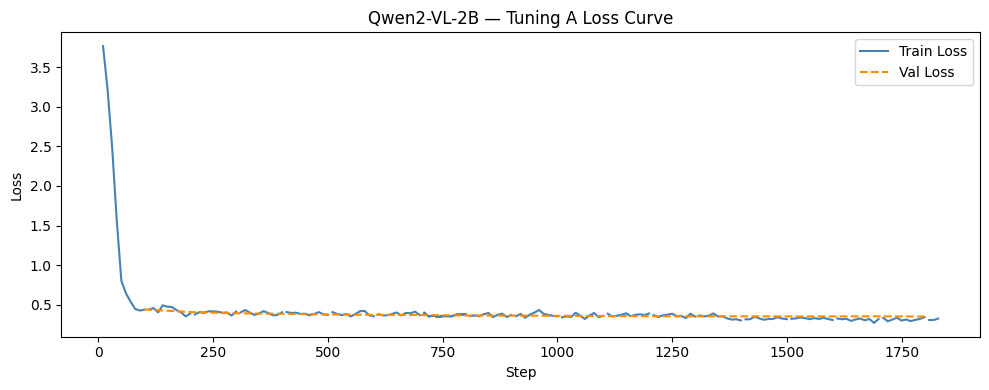

✓ Loss curve saved


In [4]:
import matplotlib.pyplot as plt

log_df = pd.read_csv(f"{LOG_DIR}/training_log.csv")

fig, ax = plt.subplots(figsize=(10, 4))
if "loss" in log_df.columns:
    ax.plot(log_df["step"], log_df["loss"], label="Train Loss", color="steelblue")
if "eval_loss" in log_df.columns:
    ev = log_df.dropna(subset=["eval_loss"])
    ax.plot(ev["step"], ev["eval_loss"], linestyle="--", label="Val Loss", color="darkorange")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Qwen2-VL-2B — Tuning A Loss Curve")
ax.legend()
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/loss_curve_tuningA.png", dpi=150)
plt.show()
print("✓ Loss curve saved")

### 13 - Clear memory

In [ ]:
def clear_memory():
    for var in ["model", "trainer", "processor"]:
        if var in globals():
            del globals()[var]
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    gc.collect()
    print(f"VRAM allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"VRAM reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")

clear_memory()

### 14 - Evaluate on Test set

In [ ]:
model, processor = FastVisionModel.from_pretrained(
    CKPT_DIR,
    load_in_4bit=True,
)
FastVisionModel.for_inference(model)

with open(f"{DATA_DIR}/splits/test_vA.json") as f:
    test_data = json.load(f)

def extract_prediction(raw):
    raw = raw.strip().upper()
    for letter in ["A", "B", "C", "D"]:
        if raw.startswith(letter):
            return letter
    for letter in ["A", "B", "C", "D"]:
        if f"{letter})" in raw:
            return letter
    return "?"

def qwen_inference(model, processor, sample):
    image    = Image.open(sample["image_path"]).convert("RGB")
    messages = [
        {"role": "system", "content": [{"type": "text",  "text": SYSTEM_PROMPT}]},
        {"role": "user",   "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": sample["user_text"]},
        ]},
    ]
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, max_new_tokens=16, do_sample=False,
        )
    generated_ids = [
        out[len(inp):]
        for inp, out in zip(inputs["input_ids"], generated_ids)
    ]
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

correct   = 0
preds     = []
save_path = f"{RESULTS_DIR}/qwen2vl_2b_tuningA.csv"

for i, sample in enumerate(test_data):
    if i % 100 == 0:
        print(f"  [{i}/{len(test_data)}] running...")
        if preds:
            pd.DataFrame(preds).to_csv(save_path, index=False)
    try:
        raw_pred = qwen_inference(model, processor, sample)
    except Exception as e:
        raw_pred = "?"

    pred_letter = extract_prediction(raw_pred)
    gt_letter   = sample["answer"][0].upper()
    is_correct  = pred_letter == gt_letter
    correct    += is_correct
    preds.append({
        "question_id":  sample["question_id"],
        "image_name":   sample["image_name"],
        "category":     sample["category"],
        "abc_label":    sample["abc_label"],
        "raw_output":   raw_pred,
        "prediction":   pred_letter,
        "ground_truth": gt_letter,
        "correct":      is_correct,
    })

accuracy = correct / len(test_data) * 100
pd.DataFrame(preds).to_csv(save_path, index=False)
print(f"\n→ Tuning A accuracy: {accuracy:.2f}%")
print(f"✓ Saved to {save_path}")

### 15 - Detailed analysis

In [5]:
save_path = f"{RESULTS_DIR}/qwen2vl_2b_tuningA.csv"

TUNING A — DETAILED RESULTS

Overall Accuracy: 71.46%
Base (zero-shot): 69.25%
Improvement:      +2.21%

--- abcLabel vs Descriptive ---
              accuracy  count
abc_label                    
Descriptive  89.415042   1436
abcLabel     42.617450    894

--- Per Category ---
                             accuracy    n
category                                  
other                      100.000000    6
foodChainsWebs              89.604520  885
solarSystem                 88.235294   17
partsOfTheEarth             77.500000   40
eclipses                    69.230769   26
partsOfA                    68.389058  329
atomStructure               66.666667    3
volcano                     63.157895   19
photosynthesisRespiration   62.264151   53
typesOf                     61.538462  260
lifeCycles                  55.700326  307
moonPhaseEquinox            52.244898  245
faultsEarthquakes           52.000000   25
rockStrata                  52.000000   25
rockCycle                   50.00

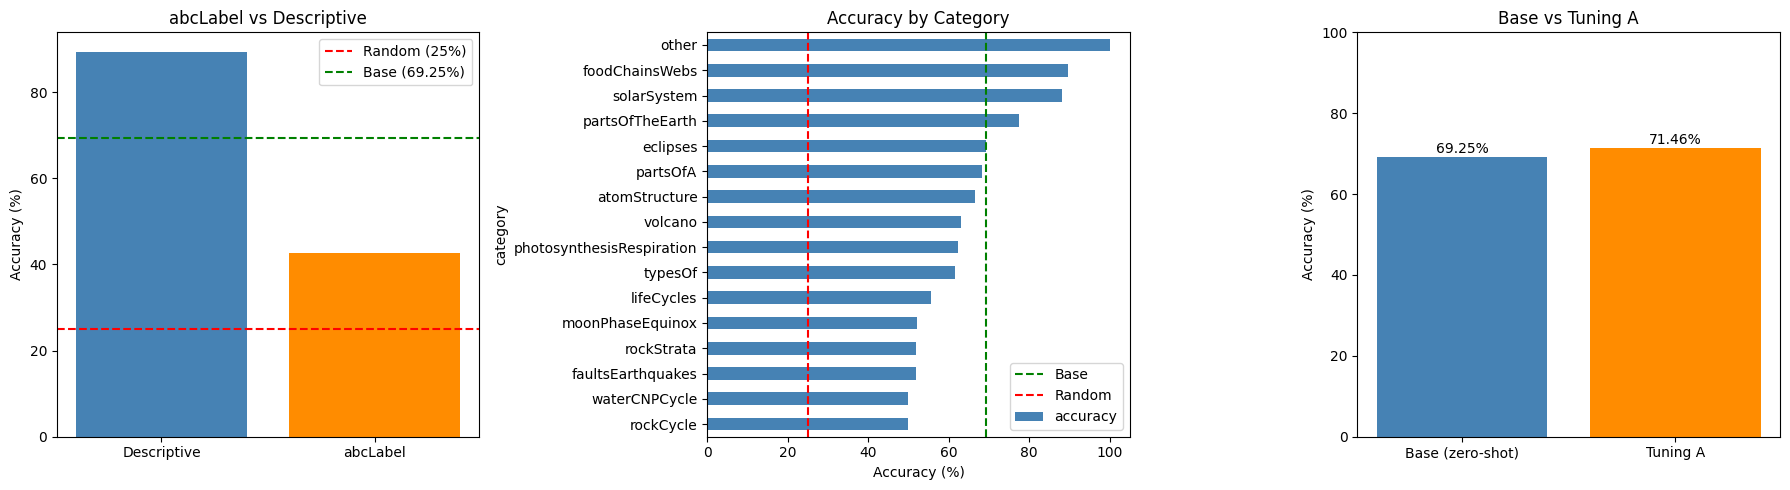

In [6]:
import seaborn as sns

df_preds = pd.read_csv(save_path)
overall  = df_preds["correct"].mean() * 100

print("="*50)
print("TUNING A — DETAILED RESULTS")
print("="*50)
print(f"\nOverall Accuracy: {overall:.2f}%")
print(f"Base (zero-shot): 69.25%")
print(f"Improvement:      {overall - 69.25:+.2f}%")

print("\n--- abcLabel vs Descriptive ---")
abc_acc = df_preds.groupby("abc_label")["correct"].agg(["mean","count"])
abc_acc["accuracy"] = abc_acc["mean"] * 100
abc_acc.index = abc_acc.index.map({True: "abcLabel", False: "Descriptive"})
print(abc_acc[["accuracy","count"]])

print("\n--- Per Category ---")
cat_acc = (
    df_preds.groupby("category")["correct"]
    .agg(["mean","count"])
    .rename(columns={"mean":"accuracy","count":"n"})
)
cat_acc["accuracy"] = cat_acc["accuracy"] * 100
print(cat_acc.sort_values("accuracy", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

abc_plot = df_preds.groupby("abc_label")["correct"].mean() * 100
abc_plot.index = ["Descriptive", "abcLabel"]
axes[0].bar(abc_plot.index, abc_plot.values, color=["steelblue","darkorange"])
axes[0].axhline(y=25,    color="red",   linestyle="--", label="Random (25%)")
axes[0].axhline(y=69.25, color="green", linestyle="--", label="Base (69.25%)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("abcLabel vs Descriptive")
axes[0].legend()

cat_acc["accuracy"].sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].axvline(x=69.25, color="green", linestyle="--", label="Base")
axes[1].axvline(x=25,    color="red",   linestyle="--", label="Random")
axes[1].set_xlabel("Accuracy (%)")
axes[1].set_title("Accuracy by Category")
axes[1].legend()

axes[2].bar(["Base (zero-shot)", "Tuning A"], [69.25, overall],
            color=["steelblue","darkorange"])
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Base vs Tuning A")
axes[2].set_ylim(0, 100)
for i, v in enumerate([69.25, overall]):
    axes[2].text(i, v + 1, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/tuningA_analysis.png", dpi=150)
plt.show()

### 16 - Save all outputs

In [ ]:
import shutil

print("Zipping outputs...")
shutil.make_archive("/kaggle/working/tuningA_final_model", "zip",
                    CKPT_DIR)
shutil.make_archive("/kaggle/working/tuningA_logs",        "zip",
                    LOG_DIR)
shutil.make_archive("/kaggle/working/tuningA_results",     "zip",
                    RESULTS_DIR)

print("Files ready for download:")
for f in ["tuningA_final_model.zip","tuningA_logs.zip","tuningA_results.zip"]:
    size = os.path.getsize(f"/kaggle/working/{f}") / 1e6
    print(f"  {f}: {size:.1f} MB")